# 03 - Feature Engineering

Notebook này hoàn thiện bước tạo đặc trưng cho bài toán dự đoán trầm cảm. Mục tiêu là biến tập dữ liệu sau tiền xử lý thành ma trận đặc trưng số, hạn chế rò rỉ dữ liệu và sẵn sàng cho notebook mô hình hóa tiếp theo.

## 3.0 Thiết lập môi trường và nạp dữ liệu

Ô code dưới đây thực hiện các việc sau:
- Nạp các thư viện cần thiết cho feature engineering và phân tích nhanh.
- Thêm thư mục `src` vào `sys.path` để import các hàm utility đã chuẩn hóa.
- Đọc dữ liệu đầu vào từ `data/processed`, là đầu ra của notebook 02.
- Khai báo tên biến mục tiêu và danh sách các cột phân loại có số lượng category lớn.

Nếu thiếu file đầu vào, notebook sẽ dừng sớm với thông báo rõ ràng để tránh chạy tiếp trên trạng thái dữ liệu sai.


In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

sys.path.insert(0, '../src')

from preprocessing_utils import (
    add_age_features,
    add_high_cardinality_target_encoding,
    add_interaction_features,
)

sns.set_theme(style='whitegrid')

TARGET = 'Depression'
HIGH_CARD_COLS = ['City', 'Profession', 'Degree']

train_path = Path('../data/processed/train_preprocessed.parquet')
test_path = Path('../data/processed/test_preprocessed.parquet')

if not train_path.exists() or not test_path.exists():
    raise FileNotFoundError(
        'Không tìm thấy file parquet trong ../data/processed/. '
        'Hãy chạy notebook 02 trước để tạo train_preprocessed.parquet và test_preprocessed.parquet.'
    )

train = pd.read_parquet(train_path)
test = pd.read_parquet(test_path)

print(f'Train shape: {train.shape}')
print(f'Test shape: {test.shape}')
print('Các cột của train:', train.columns.tolist())


Train shape: (140700, 17)
Test shape: (93800, 16)
Các cột của train: ['Gender', 'Age', 'City', 'Working Professional or Student', 'Profession', 'CGPA', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression', 'Pressure', 'Satisfaction', 'has_cgpa']


## 3.1 Target encoding cho các cột có số lượng category lớn

`City`, `Profession` và `Degree` có quá nhiều category để one-hot encoding mà không làm số chiều tăng mạnh. Vì vậy ta dùng target encoding để thay mỗi category bằng xác suất trầm cảm trung bình đã được làm mượt.

Trong notebook này, việc mã hóa được thực hiện theo kiểu out-of-fold trên tập train để tránh leakage:
- Mỗi fold validation chỉ được transform bằng encoder fit trên các fold train còn lại.
- Tập test được transform bằng encoder fit trên toàn bộ tập train sau khi hoàn thành phần out-of-fold.
- Giá trị thiếu ở các cột category được gộp về nhãn `Unknown` để xem như một category hợp lệ.


In [2]:
train, test = add_high_cardinality_target_encoding(
    train_df=train,
    test_df=test,
    cols=HIGH_CARD_COLS,
    target=TARGET,
    fill_value='Unknown',
    n_splits=5,
    smoothing=300,
    drop_original=True,
)

encoded_cols = [f'{col}_te' for col in HIGH_CARD_COLS]
print(train[encoded_cols].describe().round(4))
print('\nCác cột còn lại sau target encoding:')
print(train.columns.tolist())


           City_te  Profession_te    Degree_te
count  140700.0000    140700.0000  140700.0000
mean        0.1817         0.1823       0.1817
std         0.0337         0.2105       0.1175
min         0.0928         0.0176       0.0680
25%         0.1596         0.0489       0.1246
50%         0.1792         0.0571       0.1494
75%         0.2007         0.5331       0.1731
max         0.5791         0.5785       0.5777

Các cột còn lại sau target encoding:
['Gender', 'Age', 'Working Professional or Student', 'CGPA', 'Sleep Duration', 'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression', 'Pressure', 'Satisfaction', 'has_cgpa', 'City_te', 'Profession_te', 'Degree_te']


- Ba cột mới `City_te`, `Profession_te`, `Degree_te` phải xuất hiện và có kiểu số thực.
- Ba cột chuỗi gốc đã được loại bỏ để tránh giữ lại dữ liệu không phải số cho bước mô hình hóa.
- Miền giá trị của các cột `*_te` thường nằm gần xác suất trung bình của biến mục tiêu, không nên có giá trị dị thường quá lớn hoặc quá nhỏ.


## 3.2 Tạo các đặc trưng tương tác

Ngoài các biến gốc, một số quan hệ kết hợp có thể phản ánh trạng thái tâm lý tốt hơn từng biến riêng lẻ. Ô code dưới đây tạo thêm sáu đặc trưng:
- `stress_load`: mức stress tổng hợp từ áp lực và stress tài chính.
\begin{equation} \text{stress\_load} = \text{Pressure} * \text{Financial Stress} \tag{1} \end{equation}
- `wellbeing_index`: chỉ số tích cực kết hợp giữa mức hài lòng và giấc ngủ.
\begin{equation} \text{wellbeing\_index} = \frac{\text{Satisfaction} + \text{Sleep Duration}}{2} \tag{2} \end{equation}
- `stress_satisfaction_ratio`: áp lực tương đối so với mức hài lòng.
\begin{equation} \text{stress\_satisfaction\_ratio} = \frac{\text{Pressure}}{\text{Satisfaction} + 1} \tag{3} \end{equation}
- `hours_pressure_ratio`: tín hiệu kết hợp giữa thời lượng làm việc hoặc học tập và áp lực.
\begin{equation} \text{hours\_pressure\_ratio} = \text{"Work/Study Hours"} * \text{Pressure} \tag{4} \end{equation}
- `poor_sleep`: binary flag cho nhóm ngủ kém nhất.
\begin{equation}
\text{poor\_sleep}_i =
\begin{cases}
1 & \text{if } \text{SleepDuration}_i = 0 \\
0 & \text{otherwise}
\end{cases} \tag{5}
\end{equation}
- `cgpa_pressure`: tương tác giữa CGPA và áp lực, chỉ có ý nghĩa thực sự cho nhóm sinh viên.
\begin{equation} \text{cgpa\_pressure} = \text{CGPA} * \text{Pressure} * \text{has\_cgpa} \tag{6} \end{equation}

In [3]:
train = add_interaction_features(train)
test = add_interaction_features(test)

interaction_cols = [
    'stress_load',
    'wellbeing_index',
    'stress_satisfaction_ratio',
    'hours_pressure_ratio',
    'poor_sleep',
    'cgpa_pressure',
]

print(train[interaction_cols].describe().round(3))

       stress_load  wellbeing_index  stress_satisfaction_ratio  \
count   140700.000         140700.0                 140700.000   
mean         9.151             2.21                      0.892   
std          6.462            0.906                      0.589   
min          1.000              0.5                      0.167   
25%          4.000              1.5                      0.500   
50%          8.000              2.0                      0.750   
75%         12.000              3.0                      1.250   
max         25.000              4.0                      2.500   

       hours_pressure_ratio  poor_sleep  cgpa_pressure  
count            140700.000  140700.000     140700.000  
mean                 19.040       0.276          4.762  
std                  15.785       0.447         10.883  
min                   0.000       0.000          0.000  
25%                   6.000       0.000          0.000  
50%                  15.000       0.000          0.000  
75%   

## 3.3 Phân nhóm tuổi

Tuổi là biến liên tục, nhưng rủi ro trầm cảm có thể thay đổi theo nhóm tuổi chứ không hoàn toàn tuyến tính. Ô code dưới đây chia `Age` thành bốn nhóm thứ bậc để mô hình có thêm một cách nhìn rời rạc:
- 0: 18 đến 29
- 1: 30 đến 42
- 2: 43 đến 51
- 3: từ 52 trở lên


In [4]:
train = add_age_features(train)
test = add_age_features(test)

print(train['age_group'].value_counts().sort_index())


age_group
0    35220
1    37689
2    35047
3    32744
Name: count, dtype: int64


## 3.4 Phân tích tương quan và độ quan trọng đặc trưng

Trước khi loại bớt biến, ta cần hai góc nhìn:
- Tương quan với biến mục tiêu để xem tín hiệu tuyến tính hoặc bán tuyến tính trực tiếp.
- Độ quan trọng từ Random Forest để đo đóng góp phi tuyến ở mức baseline.

Mục tiêu của phần này là chẩn đoán trước khi chọn đặc trưng, không phải để kết luận mô hình cuối cùng.


Tương quan với biến mục tiêu:
cgpa_pressure                            0.5775
Profession_te                            0.5465
has_cgpa                                 0.5208
CGPA                                     0.5120
stress_load                              0.3509
Have you ever had suicidal thoughts ?    0.3491
hours_pressure_ratio                     0.3214
Degree_te                                0.3039
stress_satisfaction_ratio                0.2982
Pressure                                 0.2634
Financial Stress                         0.2272
Work/Study Hours                         0.1917
poor_sleep                               0.0846
City_te                                  0.0836
Family History of Mental Illness         0.0165
Gender                                   0.0081
Sleep Duration                          -0.0818
Satisfaction                            -0.1423
Dietary Habits                          -0.1488
wellbeing_index                         -0.1611
Working Pr

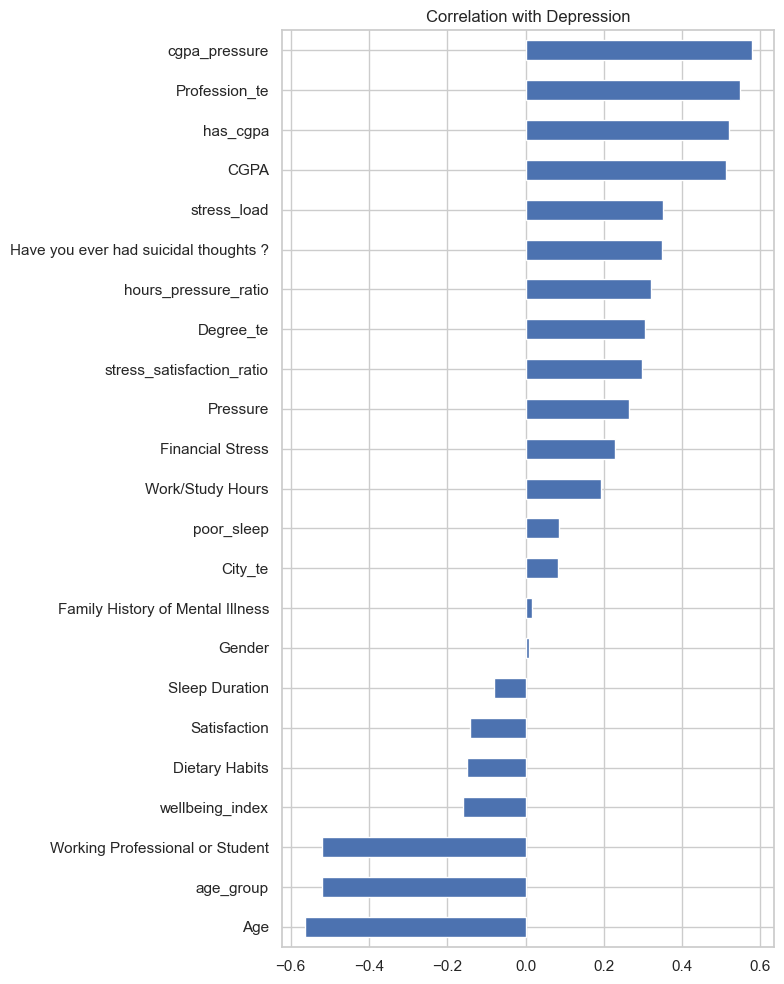


Độ quan trọng theo Random Forest:
Age                                      0.17680
age_group                                0.13917
Have you ever had suicidal thoughts ?    0.11635
cgpa_pressure                            0.11483
Profession_te                            0.08182
stress_load                              0.06642
CGPA                                     0.05461
Working Professional or Student          0.05131
stress_satisfaction_ratio                0.04122
hours_pressure_ratio                     0.03294
has_cgpa                                 0.03074
Financial Stress                         0.02379
Pressure                                 0.02168
Degree_te                                0.01334
wellbeing_index                          0.00835
Satisfaction                             0.00794
Work/Study Hours                         0.00772
Dietary Habits                           0.00731
City_te                                  0.00127
Sleep Duration                    

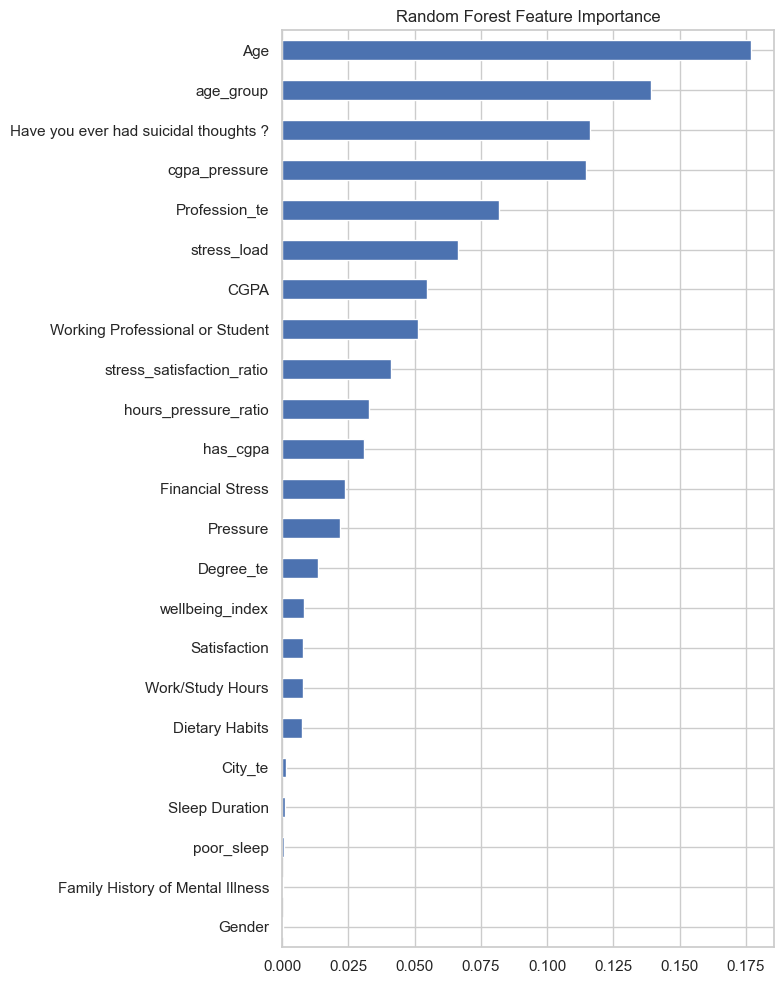

In [5]:
os.makedirs('../docs', exist_ok=True)

FEATURE_COLS = [col for col in train.columns if col != TARGET]

corr = (
    train[FEATURE_COLS + [TARGET]]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(ascending=False)
)
print('Tương quan với biến mục tiêu:')
print(corr.round(4).to_string())

plt.figure(figsize=(8, 10))
corr.sort_values().plot(kind='barh')
plt.title('Correlation with Depression')
plt.tight_layout()
plt.savefig('../docs/feat_corr.png', dpi=150)
plt.show()

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    n_jobs=-1,
    random_state=42,
)
rf.fit(train[FEATURE_COLS], train[TARGET])

imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print('\nĐộ quan trọng theo Random Forest:')
print(imp.round(5).to_string())

plt.figure(figsize=(8, 10))
imp.sort_values().plot(kind='barh')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.savefig('../docs/feat_importance.png', dpi=150)
plt.show()


### 1. Biểu đồ Tương quan với biến mục tiêu
Biểu đồ này cho thấy mối quan hệ **tuyến tính** giữa từng đặc trưng đơn lẻ với khả năng mắc trầm cảm:

* **Nhóm tương quan thuận mạnh nhất (> 0.5):** Các yếu tố như `cgpa_pressure` (0.577), `Profession_te` (0.546), `has_cgpa` (0.520) và `CGPA` (0.512) có mức độ tương quan dương rất cao. Điều này chỉ ra rằng áp lực từ điểm số học tập (CGPA) và nghề nghiệp là những nguyên nhân tuyến tính hàng đầu dẫn đến trầm cảm trong tập dữ liệu này.
* **Nhóm tương quan nghịch mạnh nhất (< -0.5):** `Age` (-0.564), `age_group` (-0.520) và `Working Professional or Student` (-0.520) cho thấy mối tương quan âm rõ rệt. Về mặt logic, điều này có khả năng ám chỉ rằng những người ở độ tuổi trẻ hơn có nguy cơ mắc trầm cảm cao hơn so với những người lớn tuổi.
* **Nhóm tương quan yếu (Gần 0):** Đáng chú ý là `Gender` (0.008), `Family History of Mental Illness` (0.016) và `poor_sleep` (0.084) gần như không có mối tương quan tuyến tính nào với biến mục tiêu. Family History và giới tính không giúp phân loại tốt trong mô hình tuyến tính cho tập dữ liệu này.

### 2. Biểu đồ Độ quan trọng Đặc trưng
Khác với Correlation, Random Forest đánh giá khả năng **phân nhánh** và bao hàm cả các mối quan hệ **phi tuyến tính**:

* **Sự vươn lên của yếu tố Tuổi tác:** `Age` (0.176) và `age_group` (0.139) trở thành hai đặc trưng quan trọng nhất để mô hình ra quyết định, vượt qua cả các chỉ số về áp lực học tập. Điều này khẳng định độ tuổi là ranh giới phân loại mạnh nhất để nhận diện rủi ro trầm cảm.
* **Dấu hiệu nghiêm trọng (Suicidal thoughts):** Đặc trưng `Have you ever had suicidal thoughts ?` nhảy vọt lên vị trí top 3 (0.116) trong Random Forest dù mức độ tương quan tuyến tính chỉ ở mức khá (0.349). Điều này cho thấy đây là một node cực kỳ quan trọng để mô hình phân loại các trường hợp trầm cảm rõ rệt.
* **Sự suy giảm do Đa cộng tuyến:** `has_cgpa` có tương quan tuyến tính rất cao (0.520) nhưng lại rớt hạng thê thảm trong Random Forest (0.030). Lý do là vì thuật toán cây quyết định đã chọn các biến mang nhiều thông tin chi tiết hơn như `cgpa_pressure` (0.114) hoặc `CGPA` (0.054) để phân nhánh, làm cho biến nhị phân `has_cgpa` trở nên dư thừa.

### 3. Tổng kết & Insight rút ra
1.  **Chân dung rủi ro:** Tập dữ liệu này chỉ ra rằng đối tượng dễ bị trầm cảm nhất là **những người trẻ tuổi**, những người đang chịu **áp lực rất lớn về mặt thành tích và định hướng nghề nghiệp**.
2.  **Lựa chọn đặc trưng:** Có thể cân nhắc **loại bỏ** các cột như `Gender`, `Family History of Mental Illness`, `Sleep Duration`, `City_te` vì chúng đóng góp rất ít (gần như bằng 0) trong cả hai phương pháp đánh giá. Việc này giúp giảm nhiễu (noise) cho các mô hình sau này.

## 3.5 Chọn đặc trưng

Mục tiêu của bước này là loại bỏ những biến vừa yếu về tương quan, vừa yếu về độ quan trọng mô hình.


In [6]:
CORR_THRESH = 0.05
IMP_THRESH = imp.mean()

weak_corr = set(corr[corr.abs() < CORR_THRESH].index)
weak_imp = set(imp[imp < IMP_THRESH].index)
to_drop = sorted(list(weak_corr & weak_imp))

print(f'Số đặc trưng bị loại: {len(to_drop)}')
print('Danh sách đặc trưng bị loại:', to_drop)

train = train.drop(columns=to_drop)
test = test.drop(columns=to_drop)

FINAL_FEATURES = [col for col in train.columns if col != TARGET]
print(f'Số đặc trưng cuối cùng: {len(FINAL_FEATURES)}')
print(FINAL_FEATURES)

Số đặc trưng bị loại: 2
Danh sách đặc trưng bị loại: ['Family History of Mental Illness', 'Gender']
Số đặc trưng cuối cùng: 21
['Age', 'Working Professional or Student', 'CGPA', 'Sleep Duration', 'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Pressure', 'Satisfaction', 'has_cgpa', 'City_te', 'Profession_te', 'Degree_te', 'stress_load', 'wellbeing_index', 'stress_satisfaction_ratio', 'hours_pressure_ratio', 'poor_sleep', 'cgpa_pressure', 'age_group']


## 3.6 Kiểm tra dữ liệu cuối cùng

Kiểm tra:
- Không có giá trị thiếu.
- Mọi đặc trưng đầu vào đều là số.
- `Depression` chỉ tồn tại ở train.


In [7]:
assert train.isnull().sum().sum() == 0, 'Train còn giá trị thiếu.'
assert test.isnull().sum().sum() == 0, 'Test còn giá trị thiếu.'
assert TARGET in train.columns, 'Train bị thiếu biến mục tiêu.'
assert TARGET not in test.columns, 'Test đang chứa biến mục tiêu.'

non_numeric = [
    col for col in FINAL_FEATURES
    if not pd.api.types.is_numeric_dtype(train[col])
]
assert len(non_numeric) == 0, f'Vẫn còn cột không phải số: {non_numeric}'

print(f'Train shape cuối cùng: {train.shape}')
print(f'Test shape cuối cùng: {test.shape}')
print('Tất cả kiểm tra đều đạt. Dữ liệu sẵn sàng cho notebook 04.')


Train shape cuối cùng: (140700, 22)
Test shape cuối cùng: (93800, 21)
Tất cả kiểm tra đều đạt. Dữ liệu sẵn sàng cho notebook 04.


## 3.7 Lưu dữ liệu đặc trưng

Ô code dưới đây lưu cả định dạng parquet và CSV vào `data/features`. Parquet được ưu tiên cho các notebook tiếp theo vì giữ kiểu dữ liệu chính xác hơn và đọc nhanh hơn, còn CSV đóng vai trò bản sao thuận tiện để kiểm tra nhanh.


In [8]:
os.makedirs('../data/features', exist_ok=True)

train.to_parquet('../data/features/train_features.parquet', index=False)
test.to_parquet('../data/features/test_features.parquet', index=False)

train.to_csv('../data/features/train_features.csv', index=False)
test.to_csv('../data/features/test_features.csv', index=False)

print('Đã lưu dữ liệu vào ../data/features/')
print(f'train_features.parquet: {train.shape}')
print(f'test_features.parquet: {test.shape}')


Đã lưu dữ liệu vào ../data/features/
train_features.parquet: (140700, 22)
test_features.parquet: (93800, 21)


## 3.8 Kết luận

Notebook này đã hoàn tất các bước chính của feature engineering:
- Mã hóa ba cột phân loại có số lượng category lớn bằng target encoding an toàn theo out-of-fold.
- Tạo thêm các đặc trưng tương tác phản ánh stress, mức hài lòng, giấc ngủ và tín hiệu học tập.
- Phân nhóm tuổi để bổ sung góc nhìn phi tuyến cho biến `Age`.
- Dùng tương quan và Random Forest importance để sàng lọc đặc trưng.
- Kiểm tra lại dữ liệu và lưu đầu ra cho notebook mô hình hóa.

Đầu ra chính cho notebook 04:
- `data/features/train_features.parquet`
- `data/features/test_features.parquet`

Những phần chưa làm ở bước này và sẽ để sang notebook mô hình hóa:
- Scaling trong `Pipeline` để tránh leakage trong cross-validation.
- Xử lý mất cân bằng lớp bằng `class_weight`, SMOTE hoặc kỹ thuật phù hợp hơn.
- Tuning thêm các siêu tham số của encoder và mô hình ở notebook 04 hoặc 05.
